## **Part - A**

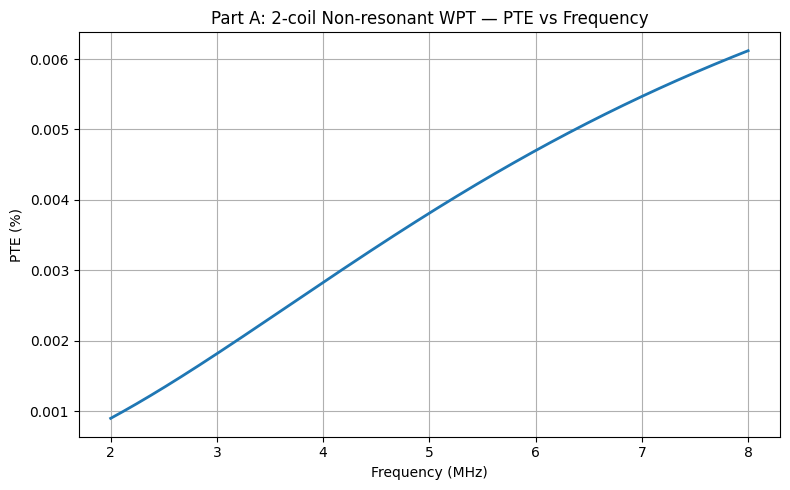

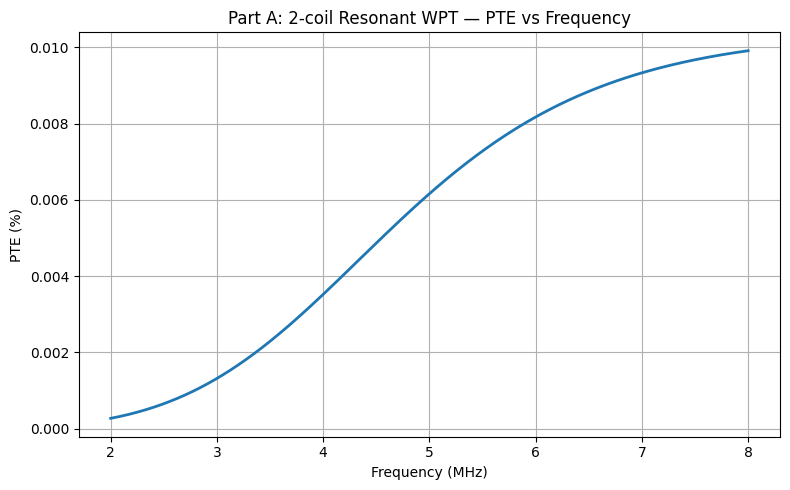


2-coil non-resonant
-------------------
Frequency range        : 2.000 to 8.000 MHz
PTE at 5 MHz           : 0.003812 %
Load power at 5 MHz    : 4.715009e-07 W
Load voltage at 5 MHz  : 4.855414e-03 V
Source loss at 5 MHz   : 1.236239e-02 W
Coil loss at 5 MHz     : 4.450630e-06 W
Input power at 5 MHz   : 1.236731e-02 W
Maximum PTE            : 0.006118 % at 8.0000 MHz
Maximum load power     : 4.996202e-07 W at 6.3684 MHz

2-coil resonant
---------------
Frequency range        : 2.000 to 8.000 MHz
PTE at 5 MHz           : 0.006163 %
Load power at 5 MHz    : 1.231943e-06 W
Load voltage at 5 MHz  : 7.848384e-03 V
Source loss at 5 MHz   : 1.998175e-02 W
Coil loss at 5 MHz     : 7.193875e-06 W
Input power at 5 MHz   : 1.999018e-02 W
Maximum PTE            : 0.009914 % at 8.0000 MHz
Maximum load power     : 1.513187e-06 W at 6.2234 MHz

Part A comparison at approximately 5 MHz
----------------------------------------
Non-resonant PTE : 0.003812 %
Resonant PTE     : 0.006163 %
Improvement fac

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The function reads the LTspice exported text file.
# LTspice stores exported magnitude values as "value,0", so only the first part is used.
def ReadLt(File):
    Raw = pd.read_csv(File, sep="\t", engine="python")
    Raw.columns = Raw.columns.str.strip()

    Df = pd.DataFrame()
    Df["FreqHz"] = Raw.iloc[:, 0].astype(float)

    for Col in Raw.columns[1:]:
        Df[Col] = Raw[Col].astype(str).str.split(",").str[0].astype(float)

    Df["FreqMHz"] = Df["FreqHz"] / 1e6
    return Df


# The function finds a required LTspice trace even if minor case differences exist.
def GetTrace(Df, Name):
    ColMap = {Col.lower(): Col for Col in Df.columns}
    Key = Name.lower()

    if Key not in ColMap:
        raise KeyError(
            f"Missing required trace: {Name}\n"
            f"Available traces are:\n{list(Df.columns)}\n\n"
            f"Re-export this current trace from LTspice."
        )

    return Df[ColMap[Key]]


# The function calculates load power, source loss, coil copper losses, and PTE.
def CalcWpt(Df, CoilR, Rs=50.0, Rl=50.0):
    Out = Df.copy()

    Is = GetTrace(Out, "mag(I(RSource))")
    Il = GetTrace(Out, "mag(I(RLoad))")

    Out["VLoad"] = Il * Rl
    Out["PLoad"] = (Il ** 2) * Rl
    Out["PSourceLoss"] = (Is ** 2) * Rs

    Out["PCoilLoss"] = 0.0

    for CoilName, CoilResistance in CoilR.items():
        Ic = GetTrace(Out, f"mag(I({CoilName}))")
        Out[f"P{CoilName}"] = (Ic ** 2) * CoilResistance
        Out["PCoilLoss"] += Out[f"P{CoilName}"]

    Out["PInput"] = Out["PLoad"] + Out["PSourceLoss"] + Out["PCoilLoss"]
    Out["PTE"] = 100 * Out["PLoad"] / Out["PInput"]

    return Out


# The function prints important numerical values for result discussion.
def PrintSum(Name, Df):
    IMaxPte = Df["PTE"].idxmax()
    IMaxPload = Df["PLoad"].idxmax()
    I5 = (Df["FreqMHz"] - 5.0).abs().idxmin()

    print(f"\n{Name}")
    print("-" * len(Name))
    print(f"Frequency range        : {Df['FreqMHz'].min():.3f} to {Df['FreqMHz'].max():.3f} MHz")
    print(f"PTE at 5 MHz           : {Df.loc[I5, 'PTE']:.6f} %")
    print(f"Load power at 5 MHz    : {Df.loc[I5, 'PLoad']:.6e} W")
    print(f"Load voltage at 5 MHz  : {Df.loc[I5, 'VLoad']:.6e} V")
    print(f"Source loss at 5 MHz   : {Df.loc[I5, 'PSourceLoss']:.6e} W")
    print(f"Coil loss at 5 MHz     : {Df.loc[I5, 'PCoilLoss']:.6e} W")
    print(f"Input power at 5 MHz   : {Df.loc[I5, 'PInput']:.6e} W")
    print(f"Maximum PTE            : {Df.loc[IMaxPte, 'PTE']:.6f} % at {Df.loc[IMaxPte, 'FreqMHz']:.4f} MHz")
    print(f"Maximum load power     : {Df.loc[IMaxPload, 'PLoad']:.6e} W at {Df.loc[IMaxPload, 'FreqMHz']:.4f} MHz")


# The function plots PTE with respect to frequency.
def PlotPte(Df, Title):
    plt.figure(figsize=(8, 5))
    plt.plot(Df["FreqMHz"], Df["PTE"], linewidth=2)
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("PTE (%)")
    plt.title(Title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# The Part A LTspice exports are loaded here.
D2N = ReadLt("2-coil_non-resonant.txt")
D2R = ReadLt("2-coil_resonant.txt")

# The 2-coil system uses two coil-resistance losses.
R2Coil = {
    "RCoil1": 0.018,
    "RCoil2": 0.018
}

# The 2-coil non-resonant and resonant results are calculated here.
R2N = CalcWpt(D2N, R2Coil)
R2R = CalcWpt(D2R, R2Coil)

# Separate PTE plots are generated for the two 2-coil cases.
PlotPte(R2N, "Part A: 2-coil Non-resonant WPT — PTE vs Frequency")
PlotPte(R2R, "Part A: 2-coil Resonant WPT — PTE vs Frequency")

# Summary values are printed for report discussion.
PrintSum("2-coil non-resonant", R2N)
PrintSum("2-coil resonant", R2R)

# The two 2-coil cases are compared at the operating frequency of 5 MHz.
I2N5 = (R2N["FreqMHz"] - 5.0).abs().idxmin()
I2R5 = (R2R["FreqMHz"] - 5.0).abs().idxmin()

Pte2N5 = R2N.loc[I2N5, "PTE"]
Pte2R5 = R2R.loc[I2R5, "PTE"]

print("\nPart A comparison at approximately 5 MHz")
print("----------------------------------------")
print(f"Non-resonant PTE : {Pte2N5:.6f} %")
print(f"Resonant PTE     : {Pte2R5:.6f} %")

if Pte2N5 > 0:
    Gain2 = Pte2R5 / Pte2N5
    print(f"Improvement factor: {Gain2:.3f}x")

## **Part - B**

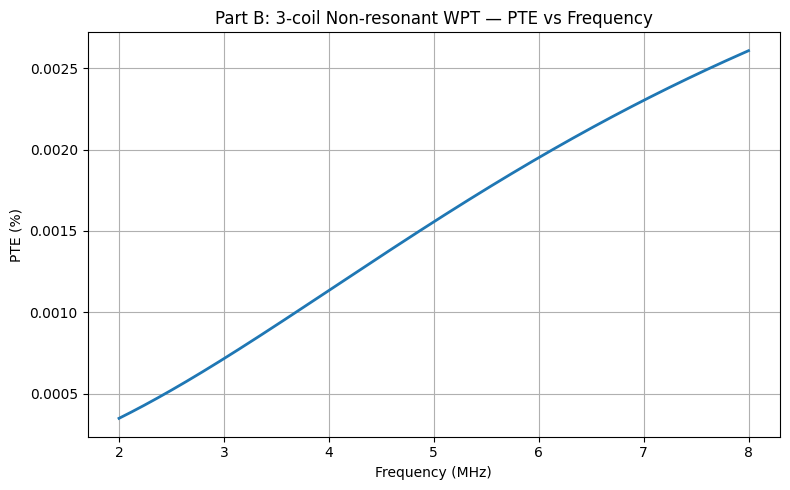

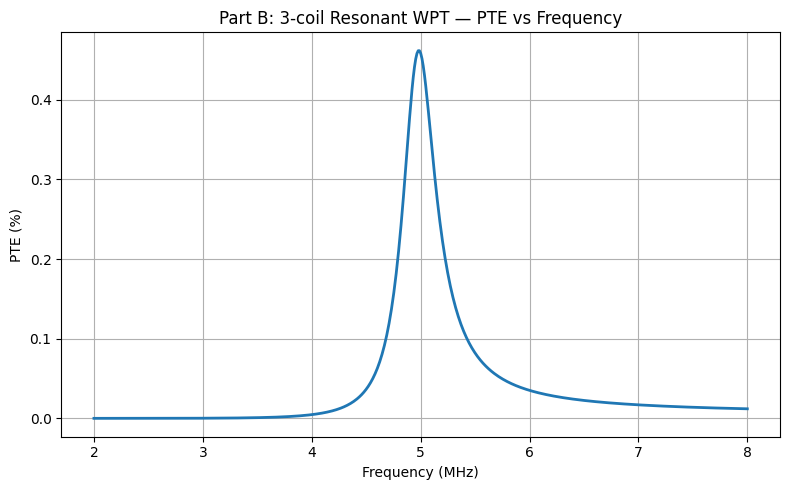


3-coil non-resonant
-------------------
Frequency range        : 2.000 to 8.000 MHz
PTE at 5 MHz           : 0.001556 %
Load power at 5 MHz    : 2.575981e-08 W
Load voltage at 5 MHz  : 1.134897e-03 V
Source loss at 5 MHz   : 1.653957e-03 W
Coil loss at 5 MHz     : 1.554999e-06 W
Input power at 5 MHz   : 1.655538e-03 W
Maximum PTE            : 0.002608 % at 8.0000 MHz
Maximum load power     : 2.875092e-08 W at 3.2436 MHz

3-coil resonant
---------------
Frequency range        : 2.000 to 8.000 MHz
PTE at 5 MHz           : 0.458284 %
Load power at 5 MHz    : 9.110797e-05 W
Load voltage at 5 MHz  : 6.749369e-02 V
Source loss at 5 MHz   : 1.976994e-02 W
Coil loss at 5 MHz     : 1.920764e-05 W
Input power at 5 MHz   : 1.988026e-02 W
Maximum PTE            : 0.461656 % at 4.9777 MHz
Maximum load power     : 9.169948e-05 W at 4.9892 MHz

Part B comparison at approximately 5 MHz
----------------------------------------
Non-resonant PTE : 0.001556 %
Resonant PTE     : 0.458284 %
Improvement fac

In [2]:
# The Part B LTspice exports are loaded here.
D3N = ReadLt("3-coil_non-resonant.txt")
D3R = ReadLt("3-coil_resonant.txt")

# The 3-coil system uses three coil-resistance losses.
# RCoil1 is larger because the transmitter coil has more turns / longer wire.
R3Coil = {
    "RCoil1": 0.047,
    "RCoil2": 0.018,
    "RCoil3": 0.018
}

# The 3-coil non-resonant and resonant results are calculated here.
R3N = CalcWpt(D3N, R3Coil)
R3R = CalcWpt(D3R, R3Coil)

# Separate PTE plots are generated for the two 3-coil cases.
PlotPte(R3N, "Part B: 3-coil Non-resonant WPT — PTE vs Frequency")
PlotPte(R3R, "Part B: 3-coil Resonant WPT — PTE vs Frequency")

# Summary values are printed for report discussion.
PrintSum("3-coil non-resonant", R3N)
PrintSum("3-coil resonant", R3R)

# The two 3-coil cases are compared at the operating frequency of 5 MHz.
I3N5 = (R3N["FreqMHz"] - 5.0).abs().idxmin()
I3R5 = (R3R["FreqMHz"] - 5.0).abs().idxmin()

Pte3N5 = R3N.loc[I3N5, "PTE"]
Pte3R5 = R3R.loc[I3R5, "PTE"]

print("\nPart B comparison at approximately 5 MHz")
print("----------------------------------------")
print(f"Non-resonant PTE : {Pte3N5:.6f} %")
print(f"Resonant PTE     : {Pte3R5:.6f} %")

if Pte3N5 > 0:
    Gain3 = Pte3R5 / Pte3N5
    print(f"Improvement factor: {Gain3:.3f}x")

## **Part - C**

2-coil resonant Part C values
 DistanceMm      PTE
        0.0 0.075450
        5.0 0.059582
       10.0 0.032313
       15.0 0.014427
       20.0 0.006163
       25.0 0.002685
       30.0 0.001248
       35.0 0.000592
       40.0 0.000326


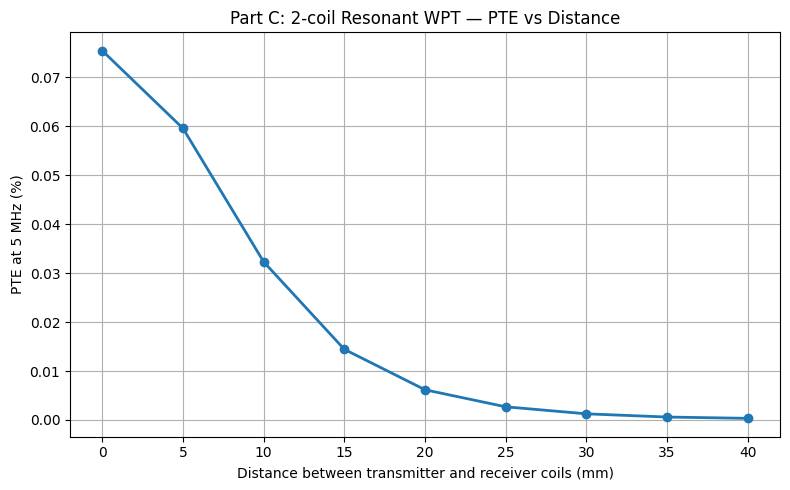


3-coil resonant Part C values
 DistanceMm      PTE
        0.0 5.343187
        5.0 4.267218
       10.0 2.360206
       15.0 1.067659
       20.0 0.458925
       25.0 0.200432
       30.0 0.093277
       35.0 0.044288
       40.0 0.024384


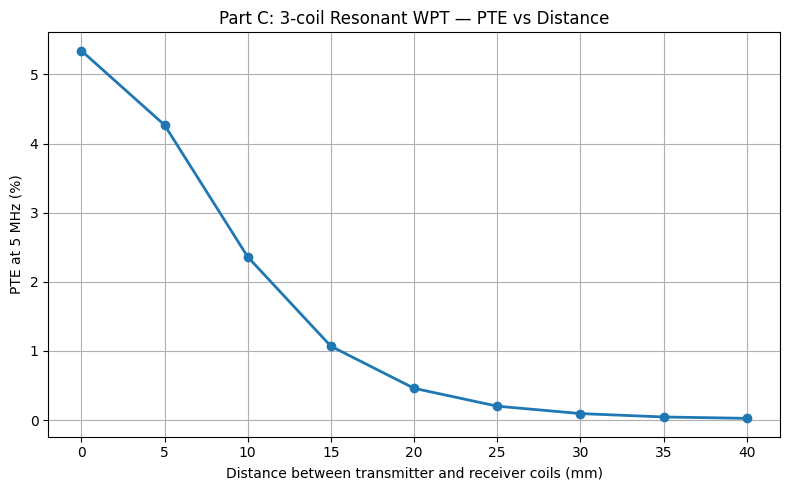


Part C Summary
--------------
2-coil PTE at 0 mm  : 0.075450 %
2-coil PTE at 20 mm : 0.006163 %
2-coil PTE at 40 mm : 0.000326 %

3-coil PTE at 0 mm  : 5.343187 %
3-coil PTE at 20 mm : 0.458925 %
3-coil PTE at 40 mm : 0.024384 %

Improvement at 20 mm: 74.46x


In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# This function reads the LTspice error log and extracts the PTE values
# from the required measurement block, such as pte2 or pte3.
def ReadPteLog(File, MeasName):
    Text = Path(File).read_text(encoding="utf-8", errors="ignore")

    # Distance values are taken from the .step lines in the LTspice log.
    Dist = [float(x) for x in re.findall(r"\.step\s+dmm=([0-9.]+)", Text, flags=re.IGNORECASE)]

    # The required measurement block is selected from the LTspice log.
    Parts = re.split(r"\nMeasurement:\s*", Text, flags=re.IGNORECASE)
    Block = None

    for Part in Parts:
        if Part.lower().startswith(MeasName.lower()):
            Block = Part
            break

    if Block is None:
        raise ValueError(f"Measurement block '{MeasName}' was not found in {File}")

    # PTE values are read from lines like:
    # 1    (0.0754498960108,0)
    Values = []

    for Line in Block.splitlines():
        Match = re.match(r"\s*\d+\s+\(([+-]?[0-9.eE+-]+),", Line)
        if Match:
            Values.append(float(Match.group(1)))

    if len(Dist) != len(Values):
        raise ValueError(
            f"Mismatch in {File}: found {len(Dist)} distance values but {len(Values)} PTE values."
        )

    return pd.DataFrame({
        "DistanceMm": Dist,
        "PTE": Values
    })


# The two LTspice Part C logs are read here.
Df2 = ReadPteLog("2coil_partC_log.txt", "pte2")
Df3 = ReadPteLog("3coil_partC_log.txt", "pte3")


# Extracted values are printed for checking/report use.
print("2-coil resonant Part C values")
print(Df2.to_string(index=False))


# Plot 1: 2-coil resonant PTE vs distance.
plt.figure(figsize=(8, 5))
plt.plot(Df2["DistanceMm"], Df2["PTE"], marker="o", linewidth=2)
plt.xlabel("Distance between transmitter and receiver coils (mm)")
plt.ylabel("PTE at 5 MHz (%)")
plt.title("Part C: 2-coil Resonant WPT — PTE vs Distance")
plt.grid(True)
plt.tight_layout()
plt.show()


print("\n3-coil resonant Part C values")
print(Df3.to_string(index=False))


# Plot 2: 3-coil resonant PTE vs distance.
plt.figure(figsize=(8, 5))
plt.plot(Df3["DistanceMm"], Df3["PTE"], marker="o", linewidth=2)
plt.xlabel("Distance between transmitter and receiver coils (mm)")
plt.ylabel("PTE at 5 MHz (%)")
plt.title("Part C: 3-coil Resonant WPT — PTE vs Distance")
plt.grid(True)
plt.tight_layout()
plt.show()


# Important comparison values are printed for the report discussion.
Pte2_0 = Df2.loc[Df2["DistanceMm"] == 0, "PTE"].iloc[0]
Pte2_20 = Df2.loc[Df2["DistanceMm"] == 20, "PTE"].iloc[0]
Pte2_40 = Df2.loc[Df2["DistanceMm"] == 40, "PTE"].iloc[0]

Pte3_0 = Df3.loc[Df3["DistanceMm"] == 0, "PTE"].iloc[0]
Pte3_20 = Df3.loc[Df3["DistanceMm"] == 20, "PTE"].iloc[0]
Pte3_40 = Df3.loc[Df3["DistanceMm"] == 40, "PTE"].iloc[0]

print("\nPart C Summary")
print("--------------")
print(f"2-coil PTE at 0 mm  : {Pte2_0:.6f} %")
print(f"2-coil PTE at 20 mm : {Pte2_20:.6f} %")
print(f"2-coil PTE at 40 mm : {Pte2_40:.6f} %")
print()
print(f"3-coil PTE at 0 mm  : {Pte3_0:.6f} %")
print(f"3-coil PTE at 20 mm : {Pte3_20:.6f} %")
print(f"3-coil PTE at 40 mm : {Pte3_40:.6f} %")
print()
print(f"Improvement at 20 mm: {Pte3_20 / Pte2_20:.2f}x")